<a href="https://colab.research.google.com/github/Deekshitha212/healthcare-triage-env/blob/main/AI_Virtual_Assistant(final_project).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import joblib

In [ ]:
df = pd.read_csv("data_full (1).csv")

In [ ]:
df.head()

,text,domain,label,split
0,set a warning for when my bank account starts ...,0,0,oos_val
1,a show on broadway,0,0,oos_val
2,who has the best record in the nfl,0,0,oos_val
3,how do i find the area of a circle,0,0,oos_val
4,how many onions do i have on hand,0,0,oos_val


In [ ]:
df.shape

(23700, 4)

In [ ]:
df.columns

Index(['text', 'domain', 'label', 'split'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23700 entries, 0 to 23699
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    23700 non-null  object
 1   domain  23700 non-null  int64 
 2   label   23700 non-null  int64 
 3   split   23700 non-null  object
dtypes: int64(2), object(2)
memory usage: 740.8+ KB


In [ ]:
df.isnull().sum()

,0
text,0
domain,0
label,0
split,0


In [ ]:
df["label"].value_counts()

,count
label,
0,1200
78,150
10,150
96,150
99,150
...,...
113,150
57,150
65,150


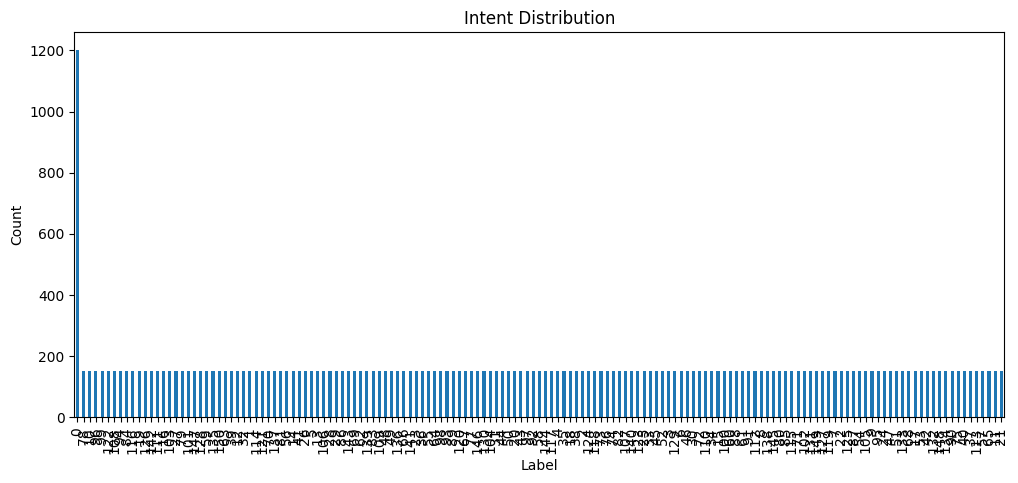

In [ ]:
df["label"].value_counts().plot(kind="bar", figsize=(12,5))

plt.title("Intent Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

In [ ]:
X = df["text"]
y = df["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(18960,)
(4740,)


In [ ]:
vectorizer = TfidfVectorizer()

In [ ]:
X_train_vector = vectorizer.fit_transform(X_train)

X_test_vector = vectorizer.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_vector, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
prediction = model.predict(X_test_vector)

In [ ]:
accuracy = accuracy_score(y_test, prediction)

print("Accuracy =", accuracy)

Accuracy = 0.8886075949367088


In [ ]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.44      0.89      0.59       236
           1       0.94      0.91      0.92        33
           2       1.00      1.00      1.00        29
           3       1.00      0.97      0.98        31
           4       0.86      0.86      0.86        28
           5       0.97      1.00      0.98        29
           6       0.88      0.95      0.91        22
           7       0.97      0.97      0.97        30
           8       1.00      0.93      0.96        28
           9       0.83      0.76      0.79        25
          10       1.00      0.94      0.97        35
          11       1.00      0.97      0.98        33
          12       0.97      0.94      0.95        32
          13       0.92      0.89      0.91        27
          14       0.96      0.79      0.86        28
          15       1.00      0.87      0.93        39
          16       0.89      0.82      0.85        38
          17       0.97    

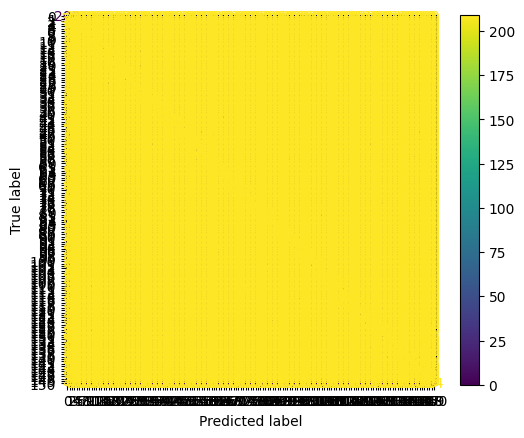

In [ ]:
cm = confusion_matrix(y_test, prediction)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

In [ ]:
joblib.dump(model, "intent_model.pkl")

joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']

In [ ]:
model = joblib.load("intent_model.pkl")

vectorizer = joblib.load("vectorizer.pkl")

print("AI Virtual Assistant Started")

AI Virtual Assistant Started


In [ ]:
while True:

    user = input("You : ")

    if user.lower() == "exit":
        print("Assistant : Goodbye!")
        break

    text = vectorizer.transform([user])

    prediction = model.predict(text)

    print("Predicted Intent :", prediction[0])